In [1]:
import os, sys, pickle
import numpy as np
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn as nn
from torchinfo import summary
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
import albumentations as A
sns.set()

sys.path.append(os.path.abspath("."))
from src_vae.train import train_vae
from src_vae.model import VAEModel
from src_vae.data import ZiramF0Dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

import datetime

/hps/software/users/birney/esther/micromamba/envs/indigene-img-umap/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2264: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/hps/software/users/birney/esther/micromamba/envs/indigene-img-umap/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2264: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using

Using device: cuda


In [99]:
X_train = ZiramF0Dataset(img_type="full_dataset", train=True, val=False, test=False, apply_transform=True)
X_val = ZiramF0Dataset(img_type="full_dataset", train=False, val=True, test=False, apply_transform=False)

# X_test = ZiramF0Dataset(img_type="brightfield", train=False)

In [3]:
def renormalize(tensor):
    minFrom = tensor.min()
    maxFrom = tensor.max()
    minTo = 0
    maxTo=1
    return minTo + (maxTo - minTo) * ((tensor - minFrom) / (maxFrom - minFrom))

In [7]:
from src_vae.vae import VAE

batch_size = 32
vae = VAE(input_dim=(1, 352, 352),
        latent_dim=128,
        capacity=64,
        depth=5,
        batch_size=batch_size,
        device=device)

summary(vae, input_size=(batch_size, 1, 352, 352))

input_dim:  (1, 352, 352)
latent_dim:  128
capacity:  64
depth:  5
batch_size:  32
dropout:  0.0


Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [32, 1, 352, 352]         --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [32, 64, 176, 176]        --
│    │    └─Conv2d: 3-1                  [32, 64, 176, 176]        1,088
│    │    └─BatchNorm2d: 3-2             [32, 64, 176, 176]        128
│    │    └─ReLU: 3-3                    [32, 64, 176, 176]        --
│    │    └─Dropout: 3-4                 [32, 64, 176, 176]        --
│    │    └─Identity: 3-5                [32, 64, 176, 176]        --
│    └─Sequential: 2-2                   [32, 128, 88, 88]         --
│    │    └─Conv2d: 3-6                  [32, 128, 88, 88]         131,200
│    │    └─BatchNorm2d: 3-7             [32, 128, 88, 88]         256
│    │    └─ReLU: 3-8                    [32, 128, 88, 88]         --
│    │    └─Dropout: 3-9                 [32, 128, 88, 88]         --
│    

In [14]:
loader = DataLoader(X_train, batch_size=64, num_workers=4)

mean = 0.0
std = 0.0
total = 0

for images, *_ in loader:
    batch_size = images.size(0)
    images = images.view(batch_size, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total += batch_size

mean /= total
std /= total

print(mean, std)

tensor([0.6007]) tensor([0.1997])


In [6]:
vae.decode(mean = torch.rand(batch_size, 128).to(device),
           logvar = torch.rand(batch_size, 128).to(device))

tensor([[[[0.4222, 0.4047, 0.4049,  ..., 0.4559, 0.4225, 0.4327],
          [0.4838, 0.4013, 0.4030,  ..., 0.4187, 0.4534, 0.4461],
          [0.4537, 0.4622, 0.4794,  ..., 0.4298, 0.4128, 0.3942],
          ...,
          [0.4858, 0.4373, 0.3963,  ..., 0.3789, 0.4700, 0.4469],
          [0.4463, 0.4613, 0.4961,  ..., 0.3350, 0.5301, 0.4003],
          [0.4852, 0.5657, 0.5526,  ..., 0.4489, 0.4795, 0.4412]]],


        [[[0.4377, 0.4338, 0.3998,  ..., 0.4580, 0.4113, 0.4230],
          [0.4857, 0.4599, 0.4584,  ..., 0.4118, 0.5038, 0.4809],
          [0.5264, 0.4867, 0.5394,  ..., 0.4083, 0.4755, 0.4306],
          ...,
          [0.4756, 0.4660, 0.4226,  ..., 0.3669, 0.4086, 0.4838],
          [0.4905, 0.3703, 0.4542,  ..., 0.3935, 0.4821, 0.4292],
          [0.4841, 0.5281, 0.4946,  ..., 0.4811, 0.4800, 0.4210]]],


        [[[0.4452, 0.4217, 0.3912,  ..., 0.4525, 0.4019, 0.4317],
          [0.4821, 0.4313, 0.3896,  ..., 0.3950, 0.4518, 0.4602],
          [0.4477, 0.4687, 0.5435,  ..

### Training

In [3]:
model, history = train_vae(
    X_train=X_train,
    X_test=X_val,
    latent_dim=128,
    capacity=32,
    depth=5,
    batch_size=32,
    lr=1e-4,
    kld_b=1e-5,
    n_epochs=10,
    dropout_p=0.1,
    device=device,
    wandb_flag=True
)

None


wandb: Currently logged in as: ey267 (ey267-university-of-cambridge) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


input_dim:  torch.Size([1, 352, 352])
latent_dim:  128
capacity:  32
depth:  5
batch_size:  32
dropout:  0.1
Epoch 001 | train loss=42.2459 (recon=42.2459, kld=0.0305) | test loss=31.6004 (recon=31.6004, kld=0.0413)
Epoch 002 | train loss=27.3864 (recon=27.3864, kld=0.0764) | test loss=24.9111 (recon=24.9111, kld=0.1069)
Epoch 003 | train loss=16.9479 (recon=16.9479, kld=0.0595) | test loss=17.4110 (recon=17.4110, kld=0.0673)
Epoch 004 | train loss=12.2753 (recon=12.2753, kld=0.0550) | test loss=15.4927 (recon=15.4927, kld=0.0289)
Epoch 005 | train loss=9.7091 (recon=9.7091, kld=0.0415) | test loss=11.7781 (recon=11.7781, kld=0.0324)
Epoch 006 | train loss=7.6801 (recon=7.6801, kld=0.0383) | test loss=10.2080 (recon=10.2080, kld=0.0278)
Epoch 007 | train loss=6.3176 (recon=6.3176, kld=0.0328) | test loss=8.6681 (recon=8.6681, kld=0.0249)
Epoch 008 | train loss=5.3337 (recon=5.3337, kld=0.0285) | test loss=7.7726 (recon=7.7726, kld=0.0237)
Epoch 009 | train loss=4.6783 (recon=4.6783, kl

batch_train_kld_loss,▁▂▃▄▅▇▇▇██▁▆▆▆▆▅▅▄▅▅▄▄▄▄▄▄▄▄▁▃▃▁▃▃▃▃▃▃▃▃
batch_train_loss,█▇▆▅▅▄▄▄▄▄▃▃▂▂▂▂▂▂▂▂▂▁▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
batch_train_recon_loss,██▆▆▅▅▄▄▄▄▃▃▃▁▃▃▃▃▃▂▂▂▁▂▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂
batch_val_kld_loss,▂▂▂▂▂█▅▅▃▃▄▄▁▁▁▁▁▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch_val_loss,█████▆▇▆▄▅▅▄▄▄▄▃▃▃▃▃▃▃▃▃▂▃▂▁▂▃▁▂▂▂▁▂▂▁▁▁
batch_val_recon_loss,█████▆▆▆▆▅▃▄▄▃▅▃▄▄▄▄▂▃▃▂▃▃▂▃▃▃▃▃▃▂▂▂▁▂▁▂
epoch,▁▂▃▃▄▅▆▆▇█
epoch_test_kld_loss,▂█▅▁▂▁▁▁▁▁
epoch_test_loss,█▆▄▃▂▂▂▁▁▁
epoch_test_recon_loss,█▆▄▃▂▂▂▁▁▁
+3,...


In [4]:
model

VAEModel(
  (vae): VAE(
    (encoder): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.1, inplace=False)
        (4): Identity()
      )
      (1): Sequential(
        (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.1, inplace=False)
        (4): Identity()
      )
      (2): Sequential(
        (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.1, inplace=False)
        (4): Identity()
      )
      (3): Sequential(
        (0): Conv2d(128, 256, kernel_size=(4, 4), strid

### Load pretrained

In [39]:
model = VAEModel(
    input_dim=X_train[0][0].shape,
    latent_dim=256,
    capacity=32,
    depth=3,
    batch_size=16,
    device=device
)

model_dir = "/nfs/research/birney/users/esther/medaka-ziram/results/sweep_0a39n1bn/20260629-2101_young-sweep-91/"

model_ckpt = torch.load(model_dir + "model.pt")
model.load_state_dict(model_ckpt,
                      strict=False)
model.eval()

input_dim:  torch.Size([1, 352, 352])
latent_dim:  256
capacity:  32
depth:  3
batch_size:  16
dropout:  0.0


/tmp/ipykernel_1788332/475947362.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ckpt = torch.load(model_dir + "model.pt")


VAEModel(
  (vae): VAE(
    (encoder): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.0, inplace=False)
        (4): Identity()
      )
      (1): Sequential(
        (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.0, inplace=False)
        (4): Identity()
      )
      (2): Sequential(
        (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.0, inplace=False)
        (4): Flatten(start_dim=1, end_dim=-1)
      )
    )
    (decoder): ModuleList(
      (0): Linear(in_fe

### View reconstructions

3


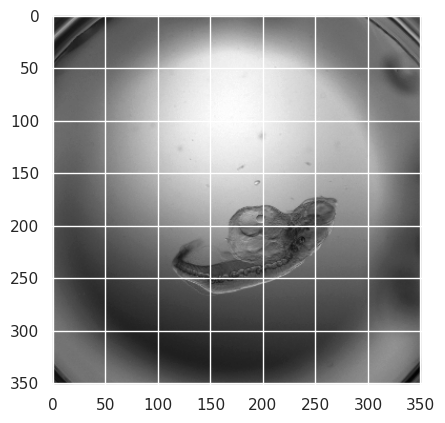

In [105]:
# sample = X_val[60]
# sample = X_val[12]
sample = X_train[0]
print(sample[5]['severity_score_adjusted'])

plt.imshow(sample[0].squeeze(0).cpu().detach(), cmap="gray")

In [8]:
X_val[0]

(tensor([[[-0.5195, -0.6293, -0.6073,  ...,  1.4340,  1.4340,  1.4340],
          [-0.6293, -0.6293, -0.8927,  ...,  1.3462,  1.4340,  1.3901],
          [-0.6512, -0.9146, -1.3316,  ...,  1.4120,  1.4120,  1.3681],
          ...,
          [-1.3316, -1.3975, -1.3975,  ...,  1.5657,  1.5657,  1.5876],
          [-1.3975, -1.4194, -1.4414,  ...,  1.5657,  1.6096,  1.5876],
          [-1.7267, -1.6609, -1.7267,  ...,  1.5657,  1.5876,  1.5437]]]),
 tensor(0.),
 array(0.),
 '/nfs/research/birney/users/esther/medaka-ziram/data/full_dataset/val/-A002--PO01--LO001--CO1--SL002--PX32500--PW0063--IN0020--TM228--X024269--Y012372--Z206500--T0000047904--WE00002.tif',
 '',
 {'generation': 'F2',
  'severity_score': 2.0,
  'severity_score_adjusted': 2,
  'kinks_number': 5,
  'plate': 'MG17',
  'well': 'A2',
  'line': '',
  'exposure_type': '',
  'cross': '58-2x117-2',
  'tank': 6412.0})

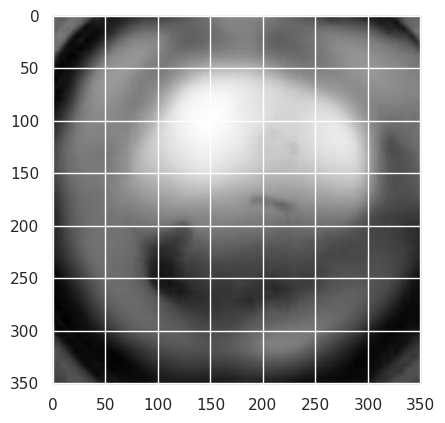

In [97]:
recon = model.vae(sample[0].unsqueeze(0).to(device))

plt.imshow(recon.squeeze(0).squeeze(0).cpu().detach(), cmap="gray")

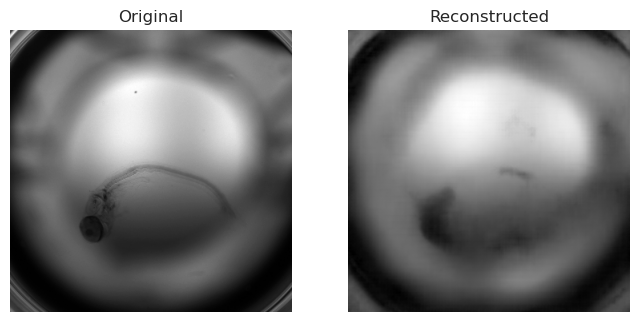

In [98]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(sample[0].squeeze(0).cpu().detach(), cmap='gray')
axs[0].set_title('Original')
axs[0].axis('off')
axs[1].imshow(recon[0].squeeze(0).squeeze(0).cpu().detach(), cmap='gray')
axs[1].set_title('Reconstructed')
axs[1].axis('off')
plt.show()

### Plot history

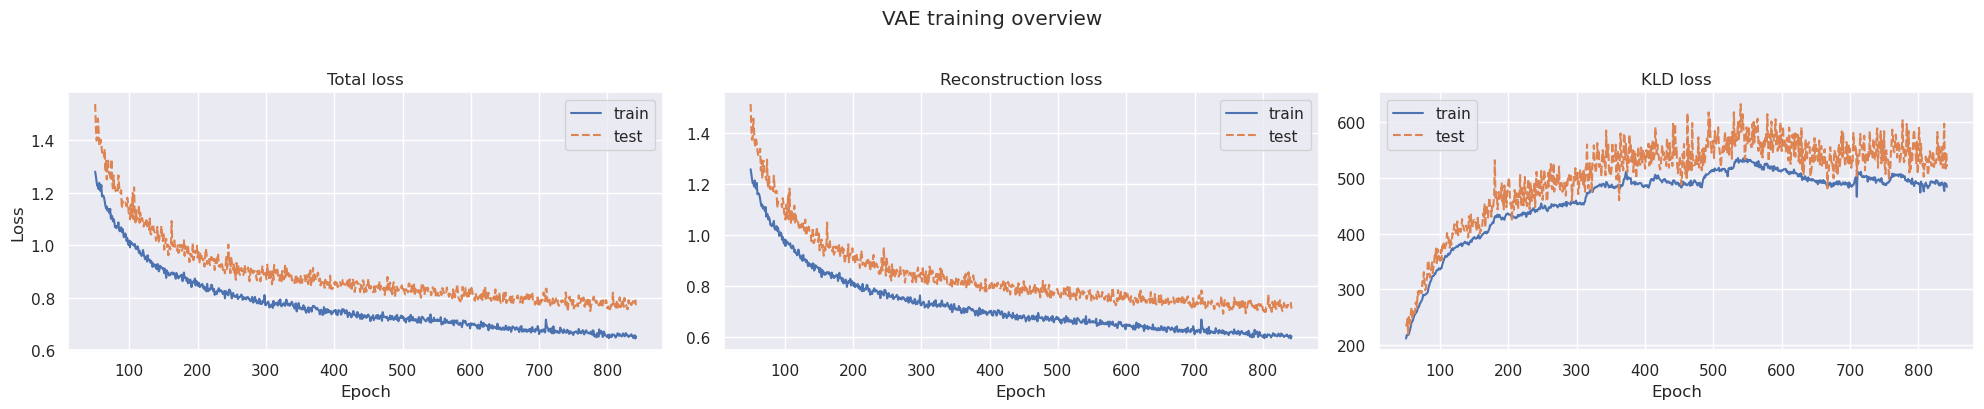

In [42]:
import pandas as pd

history_dir = model_dir
history = pd.read_csv(f"{history_dir}/history.csv")

epochs = np.arange(1, len(history["train_loss"]) + 1)

mask_val = 50
mask = epochs >= mask_val

# =========================
# 1) Global losses (1 row, 3 subplots)
# =========================
fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharex=True)

# --- total loss ---
ax = axes[0]
ax.plot(epochs[mask], history["train_loss"][mask], label="train")
ax.plot(epochs[mask], history["test_loss"][mask],  label="test", linestyle="--")
ax.set_title("Total loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

# --- recon loss ---
ax = axes[1]
ax.plot(epochs[mask], history["train_recon"][mask], label="train")
ax.plot(epochs[mask], history["test_recon"][mask],  label="test", linestyle="--")
ax.set_title("Reconstruction loss")
ax.set_xlabel("Epoch")
ax.legend()

# --- recon loss ---
ax = axes[2]
ax.plot(epochs[mask], history["train_kld"][mask], label="train")
ax.plot(epochs[mask], history["test_kld"][mask],  label="test", linestyle="--")
ax.set_title("KLD loss")
ax.set_xlabel("Epoch")
ax.legend()

fig.suptitle("VAE training overview", y=1.02)
fig.tight_layout()
plt.savefig(f"{history_dir}/losses_{mask_val}.png", dpi=300, bbox_inches='tight')
plt.show()

### Predict phenotypes of interest

In [10]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier

In [11]:
# Load all images
loader_train = DataLoader(X_train, batch_size=X_train.__len__(), shuffle=False, num_workers=1, pin_memory=True)
train_all = next(iter(loader_train))
loader_test = DataLoader(X_val, batch_size=X_val.__len__(), shuffle=False, num_workers=1, pin_memory=True)
test_all = next(iter(loader_test))

In [43]:
# Get latent mean, logvar for each sample
train_all_means, train_all_logvars = model.vae.get_latent(
    train_all[0].to(device)
)
test_all_means, test_all_logvars = model.vae.get_latent(
    test_all[0].to(device)
)
train_all_means = train_all_means.detach().cpu().numpy()
train_all_logvars = train_all_logvars.detach().cpu().numpy()
test_all_means = test_all_means.detach().cpu().numpy()
test_all_logvars = test_all_logvars.detach().cpu().numpy()

In [13]:
print(train_all_means.mean())
print(train_all_means.std())
print(train_all_logvars.mean())

1.1415507
31.944176
-38.607616


In [556]:
print(test_all_means.mean())
print(test_all_means.std())
print(test_all_logvars.mean())

0.061150383
20.071362
-28.32865


In [415]:
train_all[5].keys()

dict_keys(['generation', 'severity_score', 'severity_score_adjusted', 'kinks_number', 'plate', 'well', 'line', 'exposure_type', 'cross', 'tank'])

In [44]:
lr = LogisticRegressionCV(Cs=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 2, 10], 
                          cv=3,
                          random_state=42, 
                          penalty='l2', 
                          max_iter=1000000)
lr.fit(train_all_means, torch.nan_to_num(train_all[5]['severity_score_adjusted'], nan=-1))
print(lr.C_)  # best C found

[1.e-06 1.e-06 1.e-06 1.e-06 1.e-06]


In [45]:
### For numeric
clf = LogisticRegression(
    C=1e-6,
    random_state=42, 
    penalty='l2', 
    max_iter=1000000).fit(train_all_means, torch.nan_to_num(train_all[5]['severity_score_adjusted'], nan=-1))

### For non-numeric
# clf = LogisticRegression(
#     C=1.0, 
#     random_state=0, 
#     penalty='l2', 
#     max_iter=10000).fit(train_all_means, train_all[5]['exposure_type'])

In [24]:
# SVM classifier
clf = svm.SVC(decision_function_shape='ovr')
clf.fit(train_all_means, 
        torch.nan_to_num(train_all[5]['severity_score_adjusted'], nan=-1)
        )

SVC()

In [30]:
# RF Classifier
clf = RandomForestClassifier(n_estimators=5)
clf.fit(train_all_means, 
        torch.nan_to_num(train_all[5]['severity_score_adjusted'], nan=-1)
        )

RandomForestClassifier(n_estimators=5)

In [ ]:
# Save latents as pkl (to send to Fanny)
import pickle

data = []

for batch in loader_test:
    imgs, labels, arr, img_paths, empty, metadata = batch
    
    with torch.no_grad():
        mu, log_var = model.vae.get_latent(imgs.to(device))
    
    print(metadata)
    data.append({
        'img_paths': img_paths,
        'mu': mu.cpu().numpy(),
        'log_var': log_var.cpu().numpy(),
        'generation': metadata['generation'],
        'severity_score': metadata['severity_score'],
        'severity_score_adjusted': metadata['severity_score_adjusted'],
        'plate': metadata['plate'],
        'well': metadata['well'],
        'line': metadata['line'],
        'exposure_type': metadata['exposure_type'],
        'cross': metadata['cross'],
        'tank': metadata['tank']
    })

with open(f'{model_dir}/latents_val.pkl', 'wb') as f:
    pickle.dump(data, f)

{'generation': ['F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 'F2', 

In [55]:
with open(f'{model_dir}/latents_val.pkl', 'rb') as f:
    data = pickle.load(f)

In [56]:
data[0].keys()

dict_keys(['img_paths', 'mu', 'log_var', 'generation', 'severity_score', 'severity_score_adjusted', 'plate', 'well', 'line', 'exposure_type', 'cross', 'tank'])

In [71]:
data[0]['cross']

['58-2x117-2',
 '14-2x117-2',
 '14-2x58-2',
 '79-2x129-1',
 '14-2x58-2',
 '58-2x117-2',
 '79-2x14-2',
 '58-2x79-2',
 '129-1x14-2',
 '14-2x58-2',
 '79-2x14-2',
 '129-1x14-2',
 '129-1x58-2',
 '58-2x117-2',
 '79-2x129-1',
 '129-1x14-2',
 '129-1x14-2',
 '58-2x117-2',
 '129-1x14-2',
 '79-2x129-1',
 '14-2x58-2',
 '129-1x14-2',
 '58-2x117-2',
 '79-2x129-1',
 '14-2x117-2',
 '129-1x14-2',
 '129-1x58-2',
 '79-2x129-1',
 '14-2x58-2',
 '14-2x58-2',
 '58-2x117-2',
 '79-2x14-2',
 '129-1x58-2',
 '129-1x14-2',
 '58-2x117-2',
 '79-2x14-2',
 '58-2x117-2',
 '129-1x14-2',
 '79-2x129-1',
 '14-2x117-2',
 '79-2x14-2',
 '58-2x117-2',
 '79-2x14-2',
 '58-2x117-2',
 '129-1x58-2',
 '79-2x129-1',
 '129-1x58-2',
 '58-2x79-2',
 '58-2x117-2',
 '14-2x117-2',
 '129-1x14-2',
 '79-2x14-2',
 '129-1x58-2',
 '79-2x129-1',
 '58-2x117-2',
 '79-2x129-1',
 '14-2x58-2',
 '129-1x14-2',
 '79-2x14-2',
 '79-2x129-1',
 '129-1x14-2',
 '129-1x14-2',
 '58-2x117-2',
 '58-2x79-2',
 '14-2x117-2',
 '14-2x117-2',
 '79-2x14-2',
 '14-2x117-2',

In [66]:
X_val[0]

(tensor([[[-1.3206, -1.2354, -1.1929,  ...,  0.8941,  0.8729,  0.8941],
          [-1.1929, -1.1929, -1.1077,  ...,  0.8729,  0.9154,  0.8941],
          [-1.1077, -1.0225, -0.9160,  ...,  0.8303,  0.8516,  0.8941],
          ...,
          [-0.4049, -0.5114, -0.5753,  ..., -0.8095, -0.7669, -0.9799],
          [-0.5114, -0.4475, -0.4262,  ..., -0.7882, -0.8734, -1.0864],
          [-0.7030, -0.6605, -0.5753,  ..., -0.7669, -0.9799, -1.1929]]]),
 tensor(0.),
 array(0.),
 '/nfs/research/birney/users/esther/medaka-ziram/data/full_dataset/val/-A002--PO01--LO001--CO1--SL002--PX32500--PW0063--IN0020--TM228--X024269--Y012372--Z206500--T0000047904--WE00002.tif',
 '',
 {'generation': 'F2',
  'severity_score': 2.0,
  'severity_score_adjusted': 2,
  'kinks_number': 5,
  'plate': 'MG17',
  'well': 'A2',
  'line': '',
  'exposure_type': '',
  'cross': '58-2x117-2',
  'tank': 6412.0})

In [46]:
# For numeric
print("Train score: ", clf.score(train_all_means, torch.nan_to_num(train_all[5]['severity_score_adjusted'], nan=-1)))
print("Validation score: ", clf.score(test_all_means, torch.nan_to_num(test_all[5]['severity_score_adjusted'], nan=-1)))

# For non-numeric
# print("Train score: ", clf.score(train_all_means, train_all[5]['exposure_type']))
# print("Validation score: ", clf.score(test_all_means, test_all[5]['exposure_type']))

train_labels_pred = clf.predict(train_all_means)
test_labels_pred = clf.predict(test_all_means)

Train score:  0.9601386481802426
Validation score:  0.3627450980392157


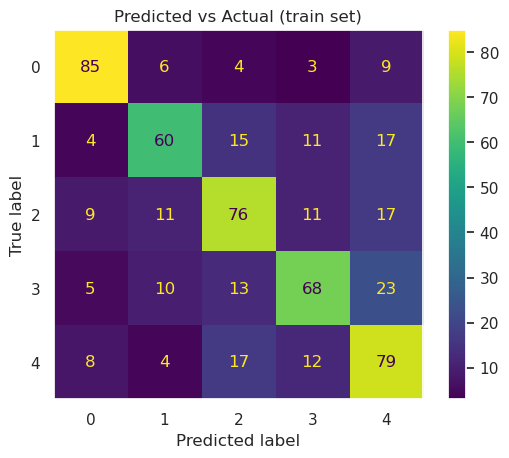

In [21]:
# ### Plot confusion matrix for training set
cm = confusion_matrix(y_true = torch.nan_to_num(train_all[5]['severity_score_adjusted'], nan=-1), 
                      y_pred = train_labels_pred, 
                      labels=clf.classes_
                      )

# cm = confusion_matrix(y_true = train_all[5]['exposure_type'], 
#                       y_pred = train_labels_pred, 
#                       labels=clf.classes_
#                       )

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

disp.plot()
plt.grid(False)
plt.title("Predicted vs Actual (train set)")
plt.show()

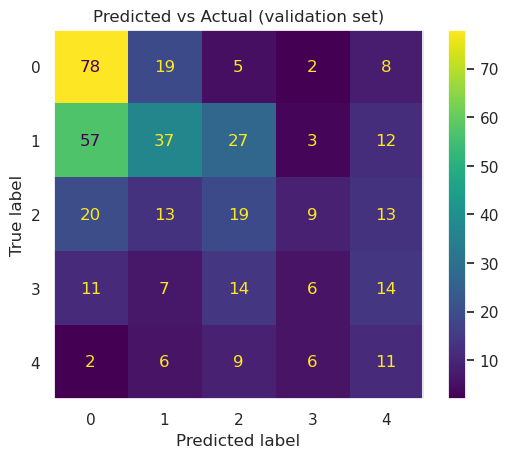

In [22]:
### Plot confusion matrix for testing set
cm = confusion_matrix(y_true = torch.nan_to_num(test_all[5]['severity_score_adjusted'], nan=-1), 
                      y_pred = test_labels_pred, 
                      labels=clf.classes_
                      )

# cm = confusion_matrix(y_true = test_all[5]['exposure_type'], 
#                       y_pred = test_labels_pred, 
#                       labels=clf.classes_
#                       )

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

disp.plot()
plt.grid(False)
plt.title("Predicted vs Actual (validation set)")
plt.show()

In [23]:
### Calculate F1 score for validation set
f1_score(y_true = torch.nan_to_num(test_all[5]['severity_score_adjusted'], nan=-1), 
         y_pred = test_labels_pred,
         average = None)

# f1_score(y_true = test_all[5]['exposure_type'], 
#          y_pred = test_labels_pred,
#          average = "macro")

array([0.55714286, 0.33944954, 0.25675676, 0.15384615, 0.23913043])

### ShapeEmbed classification code

In [579]:
train_all[5].keys()

dict_keys(['generation', 'severity_score', 'severity_score_adjusted', 'kinks_number', 'plate', 'well', 'line', 'exposure_type', 'cross', 'tank'])

In [15]:
import tqdm
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, confusion_matrix, classification_report

def run_classification( X, y, n_splits=None
                      , logreg_maxiter=200 ):
  classifiers = {
    "LogisticRegression": LogisticRegression( solver='newton-cg'
                                            , max_iter=logreg_maxiter )
  , "RandomForest": RandomForestClassifier(random_state=42)
  }
  kf = StratifiedKFold(n_splits=n_splits if n_splits else len(np.unique(y)), shuffle=True, random_state=42)
  idx_split = list(kf.split(X, y))
  eval = { nm: evaluate_classifier(clf, nm, X, y, list(kf.split(X, y)))
           for nm, clf in classifiers.items()
         }
  return { nm: { 'accuracy_mean': np.mean(accs), 'accuracy_std': np.std(accs)
               , 'micro_precision_mean': np.mean(mi_precs), 'micro_precision_std': np.std(mi_precs)
               , 'macro_precision_mean': np.mean(ma_precs), 'macro_precision_std': np.std(ma_precs)
               , 'weighted_precision_mean': np.mean(w_precs), 'weighted_precision_std': np.std(w_precs)
               , 'micro_recall_mean': np.mean(mi_recs), 'micro_recall_std': np.std(mi_recs)
               , 'macro_recall_mean': np.mean(ma_recs), 'macro_recall_std': np.std(ma_recs)
               , 'weighted_recall_mean': np.mean(w_recs), 'weighted_recall_std': np.std(w_recs)
               , 'micro_f1_mean': np.mean(mi_f1s), 'micro_f1_std': np.std(mi_f1s)
               , 'macro_f1_mean': np.mean(ma_f1s), 'macro_f1_std': np.std(ma_f1s)
               , 'weighted_f1_mean': np.mean(w_f1s), 'weighted_f1_std': np.std(w_f1s)
               , 'log_loss_mean': np.mean(loglosses), 'log_loss_std': np.std(loglosses) }
           for nm, (accs, mi_precs, ma_precs, w_precs, mi_recs, ma_recs, w_recs, mi_f1s, ma_f1s, w_f1s, loglosses, _, _) in eval.items() }

def evaluate_classifier(classifier, name, X, y, idx_splits):
  all_accuracy=[]
  micro_precision=[]
  macro_precision=[]
  weighted_precision=[]
  micro_recall=[]
  macro_recall=[]
  weighted_recall=[]
  micro_f1=[]
  macro_f1=[]
  weighted_f1=[]
  all_log_loss=[]
  all_y_test = []
  all_y_pred = []
  for train_index, test_index in (pbar:=tqdm.tqdm(idx_splits, desc=name, position=1, leave=True)):
    X_train, X_test = np.take(X, train_index, axis=0), np.take(X, test_index, axis=0)
    y_train, y_test = np.take(y, train_index, axis=0), np.take(y, test_index, axis=0)
    classifier.fit(X_train, y_train)
    all_y_test.extend(y_test)
    y_pred = classifier.predict(X_test)
    y_prob = classifier.predict_proba(X_test)
    all_y_pred.extend(y_pred)
    all_accuracy.append(accuracy_score(y_test, y_pred))
    micro_precision.append(precision_score(y_test, y_pred, average='micro'))
    macro_precision.append(precision_score(y_test, y_pred, average='macro'))
    weighted_precision.append(precision_score(y_test, y_pred, average='weighted'))
    micro_recall.append(recall_score(y_test, y_pred, average='micro'))
    macro_recall.append(recall_score(y_test, y_pred, average='macro'))
    weighted_recall.append(recall_score(y_test, y_pred, average='weighted'))
    micro_f1.append(f1_score(y_test, y_pred, average='micro'))
    macro_f1.append(f1_score(y_test, y_pred, average='macro'))
    weighted_f1.append(f1_score(y_test, y_pred, average='weighted'))
    all_log_loss.append(log_loss(y_test, y_prob, labels=classifier.classes_))
    pbar.update()
  rpt = classification_report(all_y_test, all_y_pred)
  cm = confusion_matrix(all_y_test, all_y_pred)
  return all_accuracy, micro_precision, macro_precision, weighted_precision, micro_recall, macro_recall, weighted_recall, micro_f1, macro_f1, weighted_f1, all_log_loss, rpt, cm

In [62]:
run_classification(train_all_means, train_all[5]['severity_score_adjusted'])

RandomForest: 100%|██████████| 5/5 [00:02<00:00,  1.87it/s]


{'LogisticRegression': {'accuracy_mean': np.float64(0.30502248875562216),
  'accuracy_std': np.float64(0.03840024807605978),
  'micro_precision_mean': np.float64(0.30502248875562216),
  'micro_precision_std': np.float64(0.03840024807605978),
  'macro_precision_mean': np.float64(0.31494403131120324),
  'macro_precision_std': np.float64(0.053895554095379807),
  'weighted_precision_mean': np.float64(0.3106791384378102),
  'weighted_precision_std': np.float64(0.05489382043795459),
  'micro_recall_mean': np.float64(0.30502248875562216),
  'micro_recall_std': np.float64(0.03840024807605978),
  'macro_recall_mean': np.float64(0.30870351966873705),
  'macro_recall_std': np.float64(0.03571732772625626),
  'weighted_recall_mean': np.float64(0.30502248875562216),
  'weighted_recall_std': np.float64(0.03840024807605978),
  'micro_f1_mean': np.float64(0.30502248875562216),
  'micro_f1_std': np.float64(0.03840024807605978),
  'macro_f1_mean': np.float64(0.30769148237853583),
  'macro_f1_std': np.flo

### UMAP plotting